# 03 · MongoDB depuis Python

Se connecter à une base **document** (MongoDB) avec Python, lire des documents JSON, les filtrer, les agréger et les ramener dans pandas.

> 🎯 **Cas d'usage**
>
> Vous rejoignez l'équipe data d'une application de VTC, de livraison et de location de véhicules présente dans **19 pays africains**. Le directeur des opérations prépare son comité mensuel et vous demande trois chiffres :
> 1. le **nombre de courses par mois et par type de service** (course, livraison, location) ;
> 2. le **chiffre d'affaires de novembre 2025 par devise** ;
> 3. la **note moyenne reçue par les chauffeurs**.
>
> Les données de production sont dans **MongoDB**, une base de type *document*. Vous avez un accès en **lecture seule** : à vous de les extraire proprement, et de vérifier qu'on peut s'y fier.

**Ce que vous allez apprendre**
- vous connecter à MongoDB depuis Python sans jamais exposer le mot de passe ;
- lire un document JSON : `ObjectId`, dates, sous-documents, tableaux ;
- chercher et compter avec `find`, `count_documents`, `distinct`, en faisant le lien avec SQL ;
- relier deux collections (`$lookup`) et écrire un pipeline d'agrégation (`$match` → `$group` → `$sort`) ;
- ramener les résultats dans pandas et repérer les problèmes de qualité (véracité) ;
- faire une extraction incrémentale vers un fichier Parquet daté.

**Durée indicative** : 30 minutes de parcours guidé (+ 15 minutes d'exercices).

**Prérequis** : le fichier `.env` rempli à la racine du dépôt (modèle : `.env.example`), les dépendances installées (`uv sync`), des notions de SQL (`SELECT`, `WHERE`, `GROUP BY`, `JOIN`). La fiche `docs/schema_mongodb.md` décrit chaque collection, ses champs et ses pièges de qualité : gardez-la ouverte à côté du notebook.

> ⚠️ **Base partagée, en lecture seule.** Une trentaine d'étudiants interrogent la même base en même temps. On ne fait **que des lectures** (aucun `insert`, `update`, `delete`) et des requêtes légères : on filtre, on ne demande que les champs utiles et on limite le nombre de résultats.

## 1. Se connecter à MongoDB

On commence par importer les bibliothèques. La plus importante ici est `pymongo` : c'est le **driver** MongoDB pour Python, c'est-à-dire la bibliothèque qui sait « parler » au serveur MongoDB (comme `psycopg` pour PostgreSQL).

In [1]:
import os
from datetime import date, datetime
from pathlib import Path
from pprint import pprint   # affichage lisible des dictionnaires

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from pymongo import MongoClient

Pour se connecter, MongoDB utilise une **URI** (une adresse de connexion complète) de la forme :

```
mongodb+srv://<utilisateur>:<mot de passe>@<cluster>.mongodb.net/?appName=...
```

L'URI **contient le mot de passe** : elle est rangée dans le fichier `.env` (jamais versionné sur GitHub), pas dans le notebook. `load_dotenv()` lit ce fichier et place ses valeurs dans les variables d'environnement, que l'on récupère avec `os.getenv(...)`. On vérifie qu'elle est bien chargée **sans l'afficher**.

In [2]:
load_dotenv()   # lit le fichier .env (cherché en remontant depuis notebooks/)

uri = os.getenv("MONGO_URI")
nom_base = os.getenv("MONGO_DB")
if uri is None:
    raise ValueError("MONGO_URI introuvable : copiez .env.example en .env et remplissez-le.")

# On n'affiche JAMAIS l'URI complète : on masque tout ce qui suit le protocole
print("URI chargée :", uri.split("://")[0] + "://***")
print("Base        :", nom_base)

URI chargée : mongodb+srv://***
Base        : ride_share_v1


On crée ensuite le **client**, l'objet Python qui gère la connexion au serveur.

- `MongoClient` est « paresseux » : il ne se connecte vraiment qu'à la première commande.
- `serverSelectionTimeoutMS=10000` : si le serveur ne répond pas en 10 secondes, on obtient une erreur claire au lieu d'attendre indéfiniment.
- `client[nom_base]` sélectionne la base de données ; la commande `ping` vérifie que tout fonctionne.

In [3]:
client = MongoClient(uri, serverSelectionTimeoutMS=10000)
db = client[nom_base]   # la base « ride_share_v1 »

reponse = client.admin.command("ping")
print("Réponse du serveur :", reponse)   # {'ok': 1} = connexion réussie

Réponse du serveur : {'ok': 1}


> 💡 En cas d'erreur `ServerSelectionTimeoutError` : vérifiez le fichier `.env`, votre connexion Internet, et que le réseau (Wi-Fi de l'université, VPN, pare-feu) n'empêche pas l'accès au port 27017. Le serveur est hébergé sur MongoDB Atlas, qui n'accepte que les adresses IP autorisées : si le problème persiste, prévenez l'enseignant.

Une base MongoDB contient des **collections** (l'équivalent des tables). Listons-les avec leur taille. `estimated_document_count()` lit le nombre de documents dans les métadonnées de la collection : c'est instantané, même sur une grosse collection.

In [4]:
for nom_collection in sorted(db.list_collection_names()):
    nombre = db[nom_collection].estimated_document_count()
    print(f"{nom_collection:<12} {nombre:>8} documents")   # :<12 et :>8 alignent les colonnes

cities           8214 documents
countries          19 documents


drivers          2647 documents
maintenance     12528 documents


ratings        670918 documents
trips          335459 documents


users           20247 documents
vehicles         3254 documents


Ce que contient chaque collection : `trips` les courses, `ratings` les notes (deux par course : le client note le chauffeur et inversement), `users` les clients, `drivers` les chauffeurs, `vehicles` les véhicules, `maintenance` les interventions sur les véhicules, `cities` les villes, `countries` les pays.

**Petit dictionnaire SQL ↔ MongoDB**

| SQL (PostgreSQL) | MongoDB | Exemple dans notre base |
|---|---|---|
| base de données | base de données | `ride_share_v1` |
| table | **collection** | `trips`, `drivers`… |
| ligne | **document** (un objet JSON) | une course |
| colonne | **champ** | `serviceType`, `amount` |
| clé primaire `id` | `_id` (souvent un `ObjectId`) | `ObjectId('6893…')` |
| `SELECT col1, col2` | **projection** | `{"name": 1, "currency": 1}` |
| `WHERE` | **filtre** de `find` / étape `$match` | `{"serviceType": "delivery"}` |
| `GROUP BY` | étape `$group` | chiffre d'affaires par devise |
| `ORDER BY` / `LIMIT` | `.sort()` / `.limit()` (ou `$sort` / `$limit`) | les 5 plus récentes |
| `JOIN` | étape `$lookup` | chauffeur → pays |
| schéma fixe (`CREATE TABLE`) | schéma **souple**, porté par chaque document | voir section 2 |

## 2. Lire un document

`find_one()` renvoie **un seul** document (le premier trouvé). Côté Python, un document est simplement un **dictionnaire**. On écrit `db.trips` (ou `db["trips"]`) pour désigner la collection `trips`. `pprint` (« pretty print ») affiche le dictionnaire avec une indentation lisible.

In [5]:
course = db.trips.find_one()
pprint(course)

{'_id': ObjectId('68932b9d00600df87ac544ac'),
 'acceptedAt': datetime.datetime(2025, 11, 21, 16, 22, 19, 512000),
 'amount': 2779.3340900417015,
 'currency': 'SLL',
 'destination': {'coordinates': [114.339762, -54.625561], 'type': 'Point'},
 'driverId': ObjectId('68932b8700600df87ac52fd3'),
 'endedAt': datetime.datetime(2025, 11, 21, 17, 6, 13, 512000),
 'fare': {'amount': 2779.3340900417015,
          'breakdown': {'base': 757.9614589030713,
                        'distance': 2735.1317931362128,
                        'time': 809.1405860269375},
          'currency': 'SLL'},
 'origin': {'coordinates': [78.717465, 26.849791], 'type': 'Point'},
 'requestedAt': datetime.datetime(2025, 11, 21, 16, 16, 16, 512000),
 'serviceDetails': {'packageWeightKg': None, 'rentalDurationMins': None},
 'serviceType': 'ride',
 'startedAt': datetime.datetime(2025, 11, 21, 16, 24, 52, 512000),
 'status': 'completed',
 'userId': ObjectId('68932b4600600df87ac4e09f'),
 'vehicleId': ObjectId('68932b9000600df

Quatre choses à remarquer dans ce document :

- **`_id`** : un `ObjectId`, l'identifiant unique créé par MongoDB (12 octets : une date de création, une partie aléatoire et un compteur). C'est l'équivalent de la clé primaire.
- **Les dates** (`requestedAt`, `endedAt`…) : de vraies dates, que `pymongo` convertit en objets `datetime` Python. MongoDB les stocke en temps universel (UTC).
- **Les sous-documents** : `fare` est un dictionnaire dans le dictionnaire, qui contient lui-même `breakdown` (le détail du prix).
- **Les tableaux** : `origin.coordinates` est une liste `[longitude, latitude]`. Attention à l'ordre : la longitude vient d'abord (convention GeoJSON).

Enfin, `userId`, `driverId` et `vehicleId` sont des **références** vers d'autres collections, comme des clés étrangères… mais sans aucun contrôle par la base. On accède à chaque élément comme dans n'importe quel dictionnaire Python :

In [6]:
print("Type de _id          :", type(course["_id"]))
print("Date cachée dans _id :", course["_id"].generation_time)
print("Type de requestedAt  :", type(course["requestedAt"]))
print("Demandée le          :", course["requestedAt"])
print("Prix de base         :", course["fare"]["breakdown"]["base"])   # sous-document
print("Départ [lon, lat]    :", course["origin"]["coordinates"])       # tableau

Type de _id          : <class 'bson.objectid.ObjectId'>
Date cachée dans _id : 2025-08-06 10:17:01+00:00
Type de requestedAt  : <class 'datetime.datetime'>
Demandée le          : 2025-11-21 16:16:16.512000
Prix de base         : 757.9614589030713
Départ [lon, lat]    : [78.717465, 26.849791]


> 💡 La date cachée dans l'`_id` est la date de création de l'identifiant, c'est-à-dire en pratique la date d'**insertion** du document dans la base, pas la date de la course. Ici, toutes les courses ont été insérées le 6 août 2025… y compris celle-ci, « demandée » le 21 novembre 2025 ! Une vraie course ne peut pas être enregistrée trois mois avant d'avoir été demandée : ce sont des **données synthétiques** (générées par programme), chargées en une seule fois. Premier réflexe de véracité : savoir d'où viennent les dates qu'on utilise.

**Un schéma souple.** Dans une table SQL, toutes les lignes ont les mêmes colonnes. Dans MongoDB, chaque document peut avoir sa propre forme. Ici, le poids du colis `serviceDetails.packageWeightKg` n'est rempli **que pour les livraisons** (`delivery`). Comparons un document de chaque type de service.

Le 2ᵉ argument de `find_one` est une **projection** : la liste des champs à renvoyer (`1` = garder ; `"_id": 0` = ne pas renvoyer l'`_id`, qui est renvoyé par défaut).

In [7]:
projection = {"_id": 0, "serviceType": 1, "serviceDetails": 1}

for type_service in ["ride", "delivery", "rental"]:
    document = db.trips.find_one({"serviceType": type_service}, projection)
    print(document)

{'serviceType': 'ride', 'serviceDetails': {'rentalDurationMins': None, 'packageWeightKg': None}}


{'serviceType': 'delivery', 'serviceDetails': {'rentalDurationMins': None, 'packageWeightKg': 20.692468607112485}}


{'serviceType': 'rental', 'serviceDetails': {'rentalDurationMins': None, 'packageWeightKg': None}}


> ⚠️ « Sans schéma » (*schemaless*) ne veut pas dire « sans règles » : le schéma est dans le code de l'application qui écrit les données (MongoDB permet aussi d'ajouter des règles de validation, mais elles sont facultatives). Remarquez aussi que `rentalDurationMins` (durée de location) est vide (`None`) même pour une location : c'est vrai pour **toutes** les courses de la base. Un champ prévu mais jamais rempli, à signaler à l'équipe qui produit la donnée.

## 3. Chercher : filtre, projection, tri, limite

`find(filtre, projection)` renvoie un **curseur** : un objet que l'on parcourt avec une boucle `for`. Le curseur va chercher les documents sur le serveur par paquets, au fur et à mesure, au lieu de tout charger d'un coup. On peut lui enchaîner `.sort(champ, sens)` et `.limit(n)`.

Premier exemple : la liste des pays, triée par nom. Le filtre vide `{}` signifie « tous les documents » ; dans `.sort("name", 1)`, `1` = ordre croissant (A → Z) et `-1` = décroissant.

In [8]:
curseur = db.countries.find({}, {"_id": 0, "name": 1, "isoCode": 1, "currency": 1}).sort("name", 1)

for pays in curseur:
    print(pays["isoCode"], "|", pays["name"], "|", pays["currency"])

BJ | Bénin | XOF
CM | Cameroon | XAF
CF | Central African Republic | XAF
CD | Congo (DRC) | CDF
CG | Congo (Republic) | XAF
CI | Côte d'Ivoire | XOF
GQ | Equatorial Guinea | XAF
GA | Gabon | XAF
GH | Ghana | GHS
GN | Guinea | XOF
GW | Guinea-Bissau | XOF
KE | Kenya | KES
ML | Mali | XOF
MR | Mauritania | XOF
NG | Nigeria | NGN
SN | Senegal | XOF
SL | Sierra Leone | SLL
TD | Tchad | XAF
TG | Togo | XOF


**Une requête, trois langages.** Comme dans le cours : « les 5 livraisons de plus de 20 kg les plus récentes ».

SQL (si `trips` était une table) :
```sql
SELECT requestedAt, packageWeightKg, amount, currency
FROM trips
WHERE serviceType = 'delivery' AND packageWeightKg > 20
ORDER BY requestedAt DESC
LIMIT 5;
```

MQL, le langage de MongoDB (dans le shell `mongosh`) — la requête est elle-même un document :
```javascript
db.trips.find(
  { serviceType: "delivery", "serviceDetails.packageWeightKg": { $gt: 20 } },
  { _id: 0, requestedAt: 1, "serviceDetails.packageWeightKg": 1, amount: 1, currency: 1 }
).sort({ requestedAt: -1 }).limit(5)
```

Python avec `pymongo` : presque identique, mais ce sont des dictionnaires Python, donc les clés et les opérateurs (`"$gt"`) sont entre guillemets.

- Deux conditions dans le même filtre = **ET** (`AND`).
- La **notation pointée** `"serviceDetails.packageWeightKg"` permet d'atteindre un champ dans un sous-document.
- `$gt` signifie *greater than* (« strictement supérieur à »).

In [9]:
filtre_livraisons_lourdes = {
    "serviceType": "delivery",                         # WHERE serviceType = 'delivery'
    "serviceDetails.packageWeightKg": {"$gt": 20},     #   AND packageWeightKg > 20
}
projection = {"_id": 0, "requestedAt": 1, "serviceDetails.packageWeightKg": 1, "amount": 1, "currency": 1}

curseur = db.trips.find(filtre_livraisons_lourdes, projection).sort("requestedAt", -1).limit(5)
for livraison in curseur:
    poids = round(livraison["serviceDetails"]["packageWeightKg"], 1)
    print(livraison["requestedAt"], "|", poids, "kg |", round(livraison["amount"]), livraison["currency"])

2025-12-04 10:16:14.512000 | 45.0 kg | 3686 SLL
2025-12-04 10:13:43.512000 | 21.6 kg | 2321 KES
2025-12-04 10:09:54.512000 | 37.0 kg | 2400 XAF
2025-12-04 10:09:11.512000 | 38.4 kg | 3803 NGN
2025-12-04 10:08:38.512000 | 32.4 kg | 684 KES


**Les opérateurs de comparaison** (ils commencent tous par `$`) :

| MongoDB | SQL | Exemple pymongo |
|---|---|---|
| `{"champ": valeur}` | `= valeur` | `{"currency": "XOF"}` |
| `$ne` | `<>` (différent) | `{"status": {"$ne": "active"}}` |
| `$gt`, `$gte` | `>`, `>=` | `{"amount": {"$gt": 5000}}` |
| `$lt`, `$lte` | `<`, `<=` | `{"mileageKm": {"$lte": 10000}}` |
| `$in`, `$nin` | `IN (…)`, `NOT IN (…)` | `{"isoCode": {"$in": ["BJ", "SN"]}}` |
| `$ne` avec `None` | `IS NOT NULL` | `{"comment": {"$ne": None}}` |
| `$exists` | pas d'équivalent : « le champ est présent » | `{"comment": {"$exists": True}}` |
| `$or` | `OR` | `{"$or": [{…}, {…}]}` |

(`None` est la valeur vide de Python, l'équivalent de `NULL` ; on verra en section 4 pourquoi `$exists` n'est pas un `IS NOT NULL`.)

Exemple avec `$in` : trois pays d'Afrique de l'Ouest à partir de leur code ISO.

In [10]:
codes = ["BJ", "SN", "TG"]

for pays in db.countries.find({"isoCode": {"$in": codes}}, {"_id": 0, "name": 1, "currency": 1}):
    print(pays)

{'name': 'Bénin', 'currency': 'XOF'}
{'name': 'Togo', 'currency': 'XOF'}
{'name': 'Senegal', 'currency': 'XOF'}


**Filtrer sur des dates.** On passe des objets `datetime` Python ; `pymongo` les convertit en dates MongoDB (une date écrite sans fuseau horaire est comprise comme une date UTC). Pour une période, prenez le réflexe de l'intervalle `[début, fin[` : `$gte` (≥) le début et `$lt` (<) la fin. On ne rate ainsi aucune seconde du dernier jour.

En SQL : `WHERE requestedAt >= '2025-11-01' AND requestedAt < '2025-12-01'`. On garde ce filtre dans une variable : il resservira plusieurs fois.

In [11]:
debut = datetime(2025, 11, 1)   # 1er novembre 2025 à 00:00 (inclus)
fin = datetime(2025, 12, 1)     # 1er décembre 2025 à 00:00 (exclu)
filtre_novembre = {"requestedAt": {"$gte": debut, "$lt": fin}}

projection = {"_id": 0, "requestedAt": 1, "serviceType": 1, "amount": 1, "currency": 1}
for course_novembre in db.trips.find(filtre_novembre, projection).sort("requestedAt", 1).limit(3):
    print(course_novembre)

{'serviceType': 'ride', 'requestedAt': datetime.datetime(2025, 11, 1, 0, 0, 16, 512000), 'currency': 'SLL', 'amount': 2660.667347999687}
{'serviceType': 'delivery', 'requestedAt': datetime.datetime(2025, 11, 1, 0, 1, 2, 512000), 'currency': 'CDF', 'amount': 1925.6945835060058}
{'serviceType': 'rental', 'requestedAt': datetime.datetime(2025, 11, 1, 0, 1, 20, 512000), 'currency': 'XOF', 'amount': 3504.228998152348}


## 4. Compter : `count_documents` et `distinct`

`count_documents(filtre)` compte les documents qui respectent un filtre : c'est le `SELECT COUNT(*) … WHERE …` de SQL. Contrairement à `estimated_document_count()`, il parcourt vraiment les données : le résultat est exact, mais plus lent sur une grosse collection.

> 💡 Réflexe sur une base partagée : **compter avant de télécharger**. On sait ainsi combien de documents on va rapatrier.

In [12]:
nb_novembre = db.trips.count_documents(filtre_novembre)
nb_livraisons_lourdes = db.trips.count_documents(filtre_livraisons_lourdes)

print("Courses demandées en novembre 2025 :", nb_novembre)
print("Livraisons de plus de 20 kg        :", nb_livraisons_lourdes)

Courses demandées en novembre 2025 : 83160
Livraisons de plus de 20 kg        : 51296


Comptons maintenant les courses qui ont un poids de colis, de deux façons : `$exists` (« le champ est présent ») et `$ne: None` (« le champ n'est pas vide », le `IS NOT NULL` de SQL).

In [13]:
champ_present = {"serviceDetails.packageWeightKg": {"$exists": True}}
champ_renseigne = {"serviceDetails.packageWeightKg": {"$ne": None}}

print("Le champ poids est présent  :", db.trips.count_documents(champ_present), "courses")
print("Le poids est renseigné      :", db.trips.count_documents(champ_renseigne), "courses")

Le champ poids est présent  : 335459 courses


Le poids est renseigné      : 111969 courses


> ⚠️ Le champ `packageWeightKg` est **présent dans toutes les courses**, mais il vaut `None` (vide) en dehors des livraisons. `$exists` les compte donc toutes ; seul `$ne: None` retrouve les livraisons. Pour un `IS NOT NULL`, utilisez `{"$ne": None}`.

`distinct(champ)` renvoie la liste des valeurs différentes d'un champ : c'est le `SELECT DISTINCT` de SQL. Très utile pour découvrir une collection.

In [14]:
print("Types de service       :", db.trips.distinct("serviceType"))
print("Devises des courses    :", db.trips.distinct("currency"))
print("Statuts des courses    :", db.trips.distinct("status"))
print("Statuts des chauffeurs :", db.drivers.distinct("status"))

Types de service       : ['delivery', 'rental', 'ride']


Devises des courses    : ['CDF', 'GHS', 'KES', 'NGN', 'SLL', 'XAF', 'XOF']


Statuts des courses    : ['completed']
Statuts des chauffeurs : ['active', 'banned', 'inactive', 'suspended']


> 💡 Toutes les courses ont le statut `completed` : la base ne contient que des courses **terminées**. Les courses annulées n'y figurent pas. À garder en tête avant de parler de « demande » au directeur.

## 5. Ramener les données dans pandas

Pour analyser, on veut un tableau (`DataFrame`). La recette :
1. `list(curseur)` lit le curseur et donne une liste de dictionnaires ;
2. `pd.DataFrame(liste)` en fait un tableau : une ligne par document, une colonne par champ.

On prend 500 courses de novembre, sans les coordonnées GPS (dans une projection, `0` = exclure ce champ) : pour explorer, un échantillon suffit.

In [15]:
curseur = db.trips.find(filtre_novembre, {"origin": 0, "destination": 0}).limit(500)
documents = list(curseur)   # c'est ici que les 500 documents sont téléchargés

courses = pd.DataFrame(documents)
print("Dimensions :", courses.shape)
courses[["_id", "serviceType", "amount", "fare", "serviceDetails"]].head(3)

Dimensions : (500, 14)


,_id,serviceType,amount,fare,serviceDetails
0,68932b9d00600df87ac544ac,ride,2779.334090,"{'amount': 2779.3340900417015, 'currency': 'SL...","{'rentalDurationMins': None, 'packageWeightKg'..."
1,68932b9d00600df87ac544d1,delivery,2577.566271,"{'amount': 2577.5662708312775, 'currency': 'SL...","{'rentalDurationMins': None, 'packageWeightKg'..."
2,68932b9d00600df87ac544e4,delivery,2746.948569,"{'amount': 2746.94856889951, 'currency': 'XOF'...","{'rentalDurationMins': None, 'packageWeightKg'..."


Problème : `fare` et `serviceDetails` restent des dictionnaires entassés dans une seule colonne, inutilisables pour calculer. `pd.json_normalize` **aplatit** les sous-documents : chaque champ imbriqué devient une colonne, nommée avec la notation pointée (`fare.breakdown.base`…).

In [16]:
courses = pd.json_normalize(documents)
print(list(courses.columns))

['_id', 'serviceType', 'userId', 'driverId', 'vehicleId', 'requestedAt', 'acceptedAt', 'startedAt', 'endedAt', 'status', 'currency', 'amount', 'fare.amount', 'fare.currency', 'fare.breakdown.base', 'fare.breakdown.distance', 'fare.breakdown.time', 'serviceDetails.rentalDurationMins', 'serviceDetails.packageWeightKg']


Dernier détail : les identifiants sont des `ObjectId`, un type propre à MongoDB que pandas, Parquet ou Excel ne savent pas gérer. On les convertit en texte avec `astype(str)`.

In [17]:
for colonne in ["_id", "userId", "driverId", "vehicleId"]:
    courses[colonne] = courses[colonne].astype(str)

courses[["_id", "serviceType", "requestedAt", "amount", "currency", "fare.breakdown.base"]].head()

,_id,serviceType,requestedAt,amount,currency,fare.breakdown.base
0,68932b9d00600df87ac544ac,ride,2025-11-21 16:16:16.512,2779.334090,SLL,757.961459
1,68932b9d00600df87ac544d1,delivery,2025-11-10 19:07:31.512,2577.566271,SLL,787.190990
2,68932b9d00600df87ac544e4,delivery,2025-11-21 11:45:25.512,2746.948569,XOF,508.960918
3,68932b9d00600df87ac544e9,rental,2025-11-23 16:15:44.512,2102.604024,SLL,576.509209
4,68932b9d00600df87ac544fa,delivery,2025-11-29 04:23:04.512,2155.798993,GHS,267.081009


## 6. Relier deux collections

Un document `drivers` (chauffeur) ne contient pas le nom de son pays, seulement `countryId`, l'`_id` d'un document de `countries`. Pour obtenir « chauffeur + nom du pays », il faut une jointure. Deux façons de faire :

- **côté serveur**, avec l'étape `$lookup` (le `JOIN` de MongoDB) ;
- **côté Python**, en extrayant les deux collections puis en les fusionnant avec `pd.merge`.

### 6.1 Côté serveur : `$lookup`

`$lookup` s'utilise dans un **pipeline d'agrégation** : une liste d'étapes que MongoDB applique l'une après l'autre (on le détaille en section 7). Ici : on prend 5 chauffeurs (`$limit`), on va chercher leur pays (`$lookup`), puis on ne garde que les champs utiles (`$project`, le `SELECT` de MongoDB).

```sql
-- Équivalent SQL
SELECT d.fullName, d.status, c.name, c.currency
FROM drivers d JOIN countries c ON c._id = d.countryId
LIMIT 5;
```

In [18]:
pipeline = [
    {"$limit": 5},
    {"$lookup": {
        "from": "countries",          # collection à joindre
        "localField": "countryId",    # champ côté drivers
        "foreignField": "_id",        # champ côté countries
        "as": "pays",                 # nom du nouveau champ (une liste)
    }},
    {"$project": {"_id": 0, "fullName": 1, "status": 1, "pays.name": 1, "pays.currency": 1}},
]
for chauffeur in db.drivers.aggregate(pipeline):
    print(chauffeur)

{'fullName': 'Susan Martinez', 'status': 'suspended', 'pays': [{'name': "Côte d'Ivoire", 'currency': 'XOF'}]}
{'fullName': 'Tammy Lewis', 'status': 'suspended', 'pays': [{'name': 'Congo (DRC)', 'currency': 'CDF'}]}
{'fullName': 'Dana Bridges', 'status': 'suspended', 'pays': [{'name': 'Guinea-Bissau', 'currency': 'XOF'}]}
{'fullName': 'Dennis Anderson', 'status': 'inactive', 'pays': [{'name': 'Gabon', 'currency': 'XAF'}]}
{'fullName': 'Matthew Watson', 'status': 'banned', 'pays': [{'name': 'Guinea-Bissau', 'currency': 'XOF'}]}


Le champ `pays` est une **liste** : `$lookup` renvoie toujours tous les documents correspondants (ici un seul). L'étape `$unwind` permet de « déplier » cette liste ; on l'utilisera dans les exercices.

> 💡 Placez `$limit` (et les filtres `$match`) **avant** `$lookup` : la jointure ne porte alors que sur 5 documents au lieu de 2 647. Sur une base partagée, ça compte.

### 6.2 Côté Python : deux extractions puis `merge`

D'abord, deux extractions : tous les chauffeurs (seulement 3 champs) et les 19 pays.

In [19]:
projection_chauffeurs = {"_id": 0, "fullName": 1, "status": 1, "countryId": 1}
chauffeurs = pd.DataFrame(list(db.drivers.find({}, projection_chauffeurs)))

liste_pays = pd.DataFrame(list(db.countries.find({}, {"name": 1, "currency": 1})))
print(len(chauffeurs), "chauffeurs et", len(liste_pays), "pays téléchargés")

2647 chauffeurs et 19 pays téléchargés


Ensuite, on prépare la clé de jointure (même nom et même type, du texte, des deux côtés) et on fusionne avec `merge`, le `JOIN` de pandas. `how="left"` correspond au `LEFT JOIN` : on garde tous les chauffeurs, même sans pays trouvé.

In [20]:
chauffeurs["countryId"] = chauffeurs["countryId"].astype(str)
liste_pays["countryId"] = liste_pays["_id"].astype(str)
liste_pays = liste_pays.rename(columns={"name": "pays", "currency": "devise"})

colonnes_pays = liste_pays[["countryId", "pays", "devise"]]
chauffeurs_pays = chauffeurs.merge(colonnes_pays, on="countryId", how="left")
chauffeurs_pays.head()

,fullName,status,countryId,pays,devise
0,Susan Martinez,suspended,68932b4200600df87ac4dd87,Côte d'Ivoire,XOF
1,Tammy Lewis,suspended,68932b4200600df87ac4dd88,Congo (DRC),CDF
2,Dana Bridges,suspended,68932b4200600df87ac4dd90,Guinea-Bissau,XOF
3,Dennis Anderson,inactive,68932b4200600df87ac4dd8e,Gabon,XAF
4,Matthew Watson,banned,68932b4200600df87ac4dd90,Guinea-Bissau,XOF


**Quelle méthode choisir ?**

| | `$lookup` (serveur) | `merge` (pandas) |
|---|---|---|
| Qui calcule ? | le serveur MongoDB | votre ordinateur |
| Données transférées | seulement le résultat | tous les documents des deux collections |
| Bon choix quand… | les collections sont grosses (670 000 notes) | les collections sont petites (2 647 chauffeurs, 19 pays) |

## 7. Pipeline d'agrégation : répondre au directeur

Un **pipeline d'agrégation** est une chaîne d'étapes, comme un tuyau : la sortie d'une étape est l'entrée de la suivante. Tout le calcul se fait sur le serveur, qui ne renvoie que le résultat.

| Étape MongoDB | Rôle | Équivalent SQL |
|---|---|---|
| `$match` | garder les documents qui respectent un filtre | `WHERE` |
| `$group` | regrouper et calculer (`$sum`, `$avg`, `$min`, `$max`) | `GROUP BY` + `SUM()`, `AVG()`… |
| `$sort` | trier | `ORDER BY` |
| `$project` | choisir, renommer ou calculer des champs | `SELECT …` |
| `$lookup` | joindre une autre collection | `JOIN` |
| `$limit` | garder les N premiers | `LIMIT` |

> 💡 Mettez `$match` **en premier** : MongoDB écarte tout de suite les documents inutiles, et les étapes suivantes travaillent sur beaucoup moins de données.

### 7.1 Chiffre d'affaires de novembre 2025 par devise et par type

```sql
-- Équivalent SQL
SELECT currency, serviceType, COUNT(*) AS nb_courses, SUM(amount) AS chiffre_affaires
FROM trips
WHERE requestedAt >= '2025-11-01' AND requestedAt < '2025-12-01'
GROUP BY currency, serviceType
ORDER BY currency, serviceType;
```

On construit les trois étapes une par une :
- **`$match`** reprend le filtre de novembre de la section 3 ;
- **`$group`** : `_id` est la clé de regroupement (ici deux champs : la devise et le type). Écrire `"$currency"`, avec un `$` devant, signifie « la valeur du champ `currency` ». `{"$sum": 1}` ajoute 1 par document (il compte), `{"$sum": "$amount"}` additionne les montants ;
- **`$sort`** trie le résultat (`_id.devise` : notation pointée dans la clé de groupe).

In [21]:
# Étape 1 — WHERE : les courses demandées en novembre 2025
etape_match = {"$match": filtre_novembre}

# Étape 2 — GROUP BY devise, type de service
etape_group = {"$group": {
    "_id": {"devise": "$currency", "type_service": "$serviceType"},
    "nb_courses": {"$sum": 1},                 # COUNT(*)
    "chiffre_affaires": {"$sum": "$amount"},   # SUM(amount)
}}

# Étape 3 — ORDER BY devise, type de service
etape_sort = {"$sort": {"_id.devise": 1, "_id.type_service": 1}}

On envoie le pipeline (la liste des trois étapes) avec `aggregate`, puis on regarde la forme du résultat.

In [22]:
resultat = list(db.trips.aggregate([etape_match, etape_group, etape_sort]))

print(len(resultat), "groupes renvoyés par le serveur. Les deux premiers :")
pprint(resultat[:2])

21 groupes renvoyés par le serveur. Les deux premiers :
[{'_id': {'devise': 'CDF', 'type_service': 'delivery'},
  'chiffre_affaires': 9791566.84736182,
  'nb_courses': 3928},
 {'_id': {'devise': 'CDF', 'type_service': 'rental'},
  'chiffre_affaires': 9674065.271297134,
  'nb_courses': 3883}]


On met ce résultat en forme pour le directeur : `json_normalize` aplatit `_id`, puis `pivot` construit un tableau croisé (une ligne par devise, une colonne par type de service). On ajoute un **contrôle** : le total des courses doit retomber sur le `count_documents` de la section 4.

In [23]:
ca = pd.json_normalize(resultat)   # "_id.devise" et "_id.type_service" deviennent des colonnes
ca = ca.rename(columns={"_id.devise": "devise", "_id.type_service": "type_service"})
print("Contrôle :", ca["nb_courses"].sum(), "courses agrégées, attendu :", nb_novembre)

tableau_ca = ca.pivot(index="devise", columns="type_service", values="chiffre_affaires")
tableau_ca["total_devise"] = tableau_ca.sum(axis=1)   # somme DANS une même devise : correct
tableau_ca.round(0).astype(int)

Contrôle : 83160 courses agrégées, attendu : 83160


type_service,delivery,rental,ride,total_devise
devise,,,,
CDF,9791567,9674065,9802613,29268245
GHS,9750731,10100174,9989629,29840535
KES,9965340,9899580,9744499,29609419
NGN,10073947,10140412,9849362,30063721
SLL,10032480,9651211,10107913,29791605
XAF,10060028,9766593,9736795,29563416
XOF,9598426,10105640,10006974,29711040


> ⚠️ On additionne uniquement **à l'intérieur d'une ligne** (une seule devise). N'additionnez **jamais** la colonne `total_devise` : 1 000 NGN (naira) et 1 000 XOF (franc CFA) ne valent pas du tout la même chose. Pour un total unique, il faudrait convertir chaque devise avec un taux de change daté… c'est-à-dire une autre source de données.

### 7.2 Nombre de courses par mois et par type de service

Pour regrouper par mois, on transforme la date en texte avec `$dateToString` : le format `"%Y-%m"` donne par exemple `"2025-11"` (équivalent PostgreSQL : `to_char(requestedAt, 'YYYY-MM')`). Pas de `$match` ici, car on veut tout l'historique : le serveur fait le calcul sur les 335 459 courses mais ne renvoie que quelques dizaines de lignes.

In [24]:
pipeline_mois = [
    {"$group": {
        "_id": {
            "mois": {"$dateToString": {"format": "%Y-%m", "date": "$requestedAt"}},
            "type_service": "$serviceType",
        },
        "nb_courses": {"$sum": 1},
    }},
    {"$sort": {"_id.mois": 1}},
]
par_mois = pd.json_normalize(list(db.trips.aggregate(pipeline_mois)))
print(len(par_mois), "lignes renvoyées par le serveur")

74 lignes renvoyées par le serveur


Même mise en forme qu'en 7.1 : un tableau croisé mois × type de service, avec des noms de colonnes en français.

In [25]:
par_mois = par_mois.rename(columns={"_id.mois": "mois", "_id.type_service": "type_service"})
courses_par_mois = par_mois.pivot(index="mois", columns="type_service", values="nb_courses")
courses_par_mois = courses_par_mois.fillna(0).astype(int)   # mois sans course d'un type -> 0
noms_francais = {"ride": "course", "delivery": "livraison", "rental": "location"}
courses_par_mois = courses_par_mois.rename(columns=noms_francais)
courses_par_mois = courses_par_mois[["course", "livraison", "location"]]   # ordre des colonnes
courses_par_mois.tail(4)

type_service,course,livraison,location
mois,,,
2025-09,14076,14037,14162
2025-10,21178,21092,21302
2025-11,27717,27768,27675
2025-12,3218,3155,3022


Et le graphique demandé : un diagramme en barres empilées, une barre par mois.

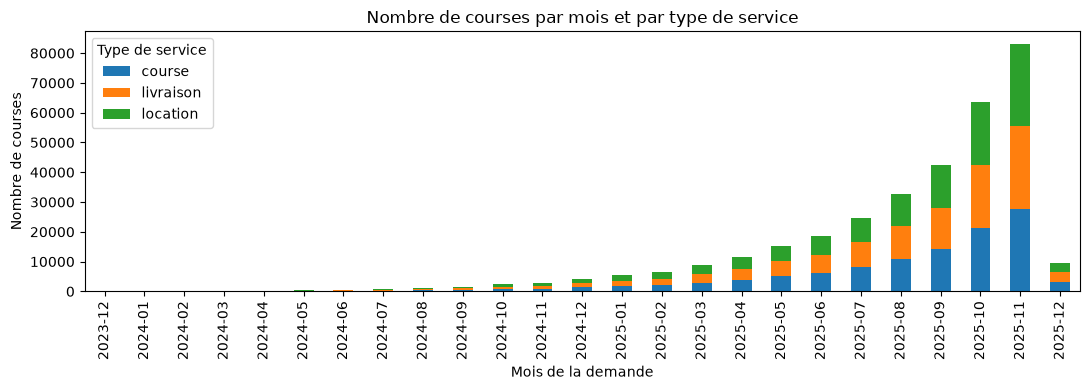

In [26]:
ax = courses_par_mois.plot(kind="bar", stacked=True, figsize=(11, 4))
ax.set_title("Nombre de courses par mois et par type de service")
ax.set_xlabel("Mois de la demande")
ax.set_ylabel("Nombre de courses")
ax.legend(title="Type de service")
plt.tight_layout()
plt.show()

L'activité est en très forte croissance : de 24 645 courses en juillet 2025 à 83 160 en novembre 2025 (× 3,4), avec une répartition presque égale entre les trois types de service.

> ⚠️ La chute de décembre 2025 n'est **pas** un effondrement de l'activité : la base s'arrête le 4 décembre 2025 (on le vérifiera en section 9), le mois est incomplet. Avant de commenter une tendance, vérifiez toujours la date de la dernière donnée.

## 8. Qualité des données : peut-on s'y fier ?

C'est le « V » de **véracité** vu en cours. Par défaut, une base document n'impose ni types, ni clés étrangères : c'est à vous de vérifier. Quelques contrôles simples, tous côté serveur.

### 8.1 Des montants en plusieurs devises

Quelles devises sont utilisées, et par quels pays ? Dans `$group`, l'opérateur `$push` construit la liste des valeurs de chaque groupe.

In [27]:
pipeline_devises = [
    {"$group": {"_id": "$currency", "pays": {"$push": "$name"}}},
    {"$sort": {"_id": 1}},
]
for devise in db.countries.aggregate(pipeline_devises):
    print(devise["_id"], ":", ", ".join(sorted(devise["pays"])))

CDF : Congo (DRC)
GHS : Ghana
KES : Kenya
NGN : Nigeria
SLL : Sierra Leone
XAF : Cameroon, Central African Republic, Congo (Republic), Equatorial Guinea, Gabon, Tchad
XOF : Bénin, Côte d'Ivoire, Guinea, Guinea-Bissau, Mali, Mauritania, Senegal, Togo


Trois enseignements :
- **Une devise ≠ un pays** : le XOF est partagé par plusieurs pays, le XAF aussi. Un chiffre d'affaires « par devise » n'est donc pas un chiffre d'affaires « par pays ».
- **Le référentiel lui-même contient des erreurs** : la Guinée utilise le franc guinéen (GNF) et la Mauritanie l'ouguiya (MRU), pas le XOF.
- **Règle d'or** : ne jamais additionner des montants de devises différentes sans conversion.

Les montants eux-mêmes sont-ils réalistes ? Calculons le prix moyen d'une course de novembre dans chaque devise, avec l'opérateur `$avg` (la moyenne, le `AVG()` de SQL).

In [28]:
pipeline_moyennes = [
    {"$match": filtre_novembre},
    {"$group": {"_id": "$currency", "montant_moyen": {"$avg": "$amount"}}},
    {"$sort": {"_id": 1}},
]
for devise in db.trips.aggregate(pipeline_moyennes):
    print(devise["_id"], ": prix moyen d'une course =", round(devise["montant_moyen"]))

CDF : prix moyen d'une course = 2497
GHS : prix moyen d'une course = 2505
KES : prix moyen d'une course = 2503
NGN : prix moyen d'une course = 2508
SLL : prix moyen d'une course = 2494
XAF : prix moyen d'une course = 2498
XOF : prix moyen d'une course = 2490


Environ 2 500 **quelle que soit la devise**. Or 1 € vaut 655,957 XOF (parité fixe), mais moins de 20 cedis ghanéens (GHS) en 2025 : la course moyenne coûterait environ 4 € au Sénégal et plus de 100 € au Ghana. Les montants ont visiblement été tirés au hasard sans tenir compte de la devise : même convertis en euros, ces chiffres d'affaires ne seraient pas réalistes.

Autre contrôle : le détail du prix (`fare.breakdown` : base + distance + temps) devrait redonner le montant facturé. Vérifions d'abord sur la course lue en section 2.

In [29]:
detail = course["fare"]["breakdown"]
somme_detail = detail["base"] + detail["distance"] + detail["time"]

print("Montant facturé          :", round(course["fare"]["amount"], 2), course["fare"]["currency"])
print("Base + distance + temps  :", round(somme_detail, 2))

Montant facturé          : 2779.33 SLL
Base + distance + temps  : 4302.23


Les deux ne correspondent pas. Cas isolé ? Refaisons le calcul sur les 500 courses du tableau `courses` de la section 5, sans nouvelle requête au serveur.

In [30]:
somme_details = (courses["fare.breakdown.base"]
                 + courses["fare.breakdown.distance"]
                 + courses["fare.breakdown.time"])
ecart = (somme_details - courses["fare.amount"]).abs()   # écart en valeur absolue

nb_justes = (ecart < 1).sum()   # chaque True compte pour 1
print("Courses dont le détail redonne le montant (à 1 près) :", nb_justes, "sur", len(courses))

Courses dont le détail redonne le montant (à 1 près) : 0 sur 500


Le détail du prix ne tombe (presque) jamais juste. Pour le chiffre d'affaires, on utilise donc `amount` (identique à `fare.amount`) et on signale l'incohérence du détail.

### 8.2 Des villes « orphelines »

Chaque ville (`cities`) pointe vers son pays par `countryId`. En SQL, une **clé étrangère** interdirait de pointer vers un pays qui n'existe pas. MongoDB, lui, ne vérifie rien. Comptons les villes orphelines : on récupère la liste des `_id` de pays avec `distinct`, puis on compte les villes dont le `countryId` n'est **pas dans** cette liste (`$nin`). Le même filtre sert ensuite pour les clients et les chauffeurs.

```sql
-- Équivalent SQL
SELECT COUNT(*) FROM cities WHERE countryId NOT IN (SELECT _id FROM countries);
```

In [31]:
ids_pays = db.countries.distinct("_id")                  # les identifiants des 19 pays
filtre_orphelines = {"countryId": {"$nin": ids_pays}}    # pays introuvable

nb_villes = db.cities.estimated_document_count()
nb_orphelines = db.cities.count_documents(filtre_orphelines)
print("Villes au total      :", nb_villes)
print("Villes orphelines    :", nb_orphelines, f"({nb_orphelines / nb_villes:.0%})")
print("Clients orphelins    :", db.users.count_documents(filtre_orphelines))
print("Chauffeurs orphelins :", db.drivers.count_documents(filtre_orphelines))

Villes au total      : 8214
Villes orphelines    : 7973 (97%)
Clients orphelins    : 0


Chauffeurs orphelins : 0


Presque toutes les villes sont orphelines ! Menons l'enquête. `distinct` accepte un filtre en 2ᵉ argument : on compte les identifiants de pays « disparus » vers lesquels pointent ces villes. Les dates cachées dans les `ObjectId` donnent un autre indice.

In [32]:
ids_pays_disparus = db.cities.distinct("countryId", filtre_orphelines)
print("Identifiants de pays disparus :", len(ids_pays_disparus))

ville_orpheline = db.cities.find_one(filtre_orphelines)
date_insertion = ville_orpheline["_id"].generation_time.date()   # date cachée dans l'ObjectId
print("Exemple de ville orpheline    :", ville_orpheline["name"], "- insérée le", date_insertion)
print("Les 19 pays actuels           : insérés le", ids_pays[0].generation_time.date())

Identifiants de pays disparus : 570


Exemple de ville orpheline    : Dan - insérée le 2025-06-16
Les 19 pays actuels           : insérés le 2025-08-06


570 pays disparus, soit 30 fois nos 19 pays, et des villes insérées dès juin 2025 : la collection `countries` a très probablement été rechargée plusieurs fois (avec de nouveaux `_id` à chaque chargement), sans supprimer les villes des chargements précédents. Bonne nouvelle : clients et chauffeurs pointent tous vers un pays valide (0 orphelin). Pour une analyse par ville, il faut donc partir des clients ou des chauffeurs, ou ne garder que les villes valides.

### 8.3 Des coordonnées GPS incohérentes

Les points de départ (`origin.coordinates` = `[longitude, latitude]`) devraient être en Afrique. Prenons un rectangle grossier autour du continent : longitude entre -18 et 52, latitude entre -35 et 38. La notation `"origin.coordinates.0"` désigne le **premier élément** du tableau (la longitude), `"origin.coordinates.1"` le second (la latitude).

In [33]:
dans_afrique = {
    "origin.coordinates.0": {"$gte": -18, "$lte": 52},   # longitude
    "origin.coordinates.1": {"$gte": -35, "$lte": 38},   # latitude
}
nb_total = db.trips.estimated_document_count()
nb_afrique = db.trips.count_documents(dans_afrique)

part_afrique = nb_afrique / nb_total
print("Départs dans le rectangle Afrique :", nb_afrique, "sur", nb_total, f"({part_afrique:.1%})")

Départs dans le rectangle Afrique : 26579 sur 335459 (7.9%)


Environ 8 % seulement. C'est exactement la part de la surface (longitude × latitude) que couvre ce rectangle : (70 / 360) × (73 / 180) ≈ 7,9 %. Les coordonnées sont donc tirées **au hasard sur toute la planète** : inutilisables pour une carte ou un calcul de distance.

**Bilan qualité, à transmettre avec vos chiffres**

| Problème constaté | Risque | Que faire |
|---|---|---|
| Montants en 7 devises | total « toutes devises » absurde | agréger par devise ; convertir avec un taux de change daté |
| Prix moyen ≈ 2 500 dans toutes les devises | montants irréalistes, même convertis | faire vérifier la façon dont les montants sont produits |
| Devise fausse pour la Guinée et la Mauritanie | chiffre d'affaires mal classé | faire corriger le référentiel `countries` |
| 97 % de villes orphelines | jointures vides | filtrer les villes valides ; signaler |
| Coordonnées GPS aléatoires | cartes et distances fausses | ne pas les utiliser |
| Détail du prix ≠ montant facturé | explications de prix fausses | utiliser `amount` uniquement |
| `rentalDurationMins` jamais rempli | durée de location inconnue | signaler à l'équipe produit |
| Seulement des courses `completed`, base arrêtée au 4/12/2025 | tendances trompeuses | préciser le périmètre et la date des données |

## 9. Extraction incrémentale vers le data lake

Rappel du cours :
- une extraction **complète** relit tout à chaque fois : simple, mais de plus en plus lourde ;
- une extraction **incrémentale** ne lit que ce qui est nouveau depuis la dernière fois, grâce à une **borne** : la date du dernier élément déjà récupéré (en SQL : `WHERE maj_le > borne`).

Ici, la borne porte sur `requestedAt`. Imaginons que l'extraction précédente a tout récupéré jusqu'au 1er décembre 2025. Comme d'habitude, on **compte avant de télécharger**.

In [34]:
borne = datetime(2025, 12, 1)   # fin de l'extraction précédente
filtre_nouveau = {"requestedAt": {"$gt": borne}}

print("Nouvelles courses depuis la borne :", db.trips.count_documents(filtre_nouveau))

Nouvelles courses depuis la borne : 9395


On télécharge ces courses en ne gardant que les champs utiles au directeur. C'est la **minimisation** (RGPD) : pas de coordonnées GPS par exemple, qui révéleraient où vivent et travaillent les clients dans une vraie base. On garde seulement les identifiants (`userId`, `driverId`…), utiles pour relier les collections, mais ni nom ni téléphone. C'est aussi plus rapide : moins d'octets à transférer.

In [35]:
champs_utiles = {"requestedAt": 1, "serviceType": 1, "amount": 1, "currency": 1,
                 "userId": 1, "driverId": 1, "vehicleId": 1}
documents = list(db.trips.find(filtre_nouveau, champs_utiles))

nouvelles_courses = pd.DataFrame(documents)
for colonne in ["_id", "userId", "driverId", "vehicleId"]:
    nouvelles_courses[colonne] = nouvelles_courses[colonne].astype(str)

print("Dimensions :", nouvelles_courses.shape)
nouvelles_courses.head(3)

Dimensions : (9395, 8)


,_id,serviceType,userId,driverId,vehicleId,requestedAt,currency,amount
0,68932b9d00600df87ac544cb,delivery,68932b4a00600df87ac51878,68932b8700600df87ac534a3,68932b9000600df87ac53a6e,2025-12-01 15:34:03.512,NGN,4291.285669
1,68932b9d00600df87ac54531,ride,68932b4a00600df87ac5157d,68932b8700600df87ac53341,68932b9000600df87ac54076,2025-12-03 07:41:24.512,XAF,3294.618828
2,68932b9d00600df87ac54589,delivery,68932b4800600df87ac4fb89,68932b8700600df87ac52fa0,68932b9000600df87ac542c5,2025-12-03 23:49:23.512,GHS,3317.624007


On enregistre le résultat **tel quel** dans la zone brute (*bronze*) du data lake, `../data/raw/mongodb/`, dans un fichier **daté** : on sait ainsi quelle borne a été utilisée et quel jour l'extraction a eu lieu. Deux formats vus en cours :
- **JSON Lines** (`.jsonl`) : un document JSON par ligne, le format naturel des exports MongoDB ;
- **Parquet** : stockage par colonnes, typé et compressé, idéal pour l'analyse.

In [36]:
DOSSIER_DATA = Path("../data")
dossier_mongo = DOSSIER_DATA / "raw" / "mongodb"
dossier_mongo.mkdir(parents=True, exist_ok=True)

nom_fichier = f"trips_depuis_{borne.date().isoformat()}_extrait_le_{date.today().isoformat()}"
fichier_parquet = dossier_mongo / (nom_fichier + ".parquet")
fichier_jsonl = dossier_mongo / (nom_fichier + ".jsonl")

nouvelles_courses.to_parquet(fichier_parquet, index=False)
nouvelles_courses.to_json(fichier_jsonl, orient="records", lines=True, date_format="iso")
print(fichier_parquet.name, ":", fichier_parquet.stat().st_size // 1024, "Ko")
print(fichier_jsonl.name, ":", fichier_jsonl.stat().st_size // 1024, "Ko")

trips_depuis_2025-12-01_extrait_le_2026-10-07.parquet : 375 Ko
trips_depuis_2025-12-01_extrait_le_2026-10-07.jsonl : 2319 Ko


Comparez les tailles : pour les mêmes données, le fichier Parquet est environ 6 fois plus léger que le JSON Lines (stockage par colonnes + compression), comme dans la démo DuckDB du cours.

Reste à préparer le **prochain** passage : la nouvelle borne est la date de la course la plus récente que l'on vient de récupérer. Dans la vraie vie, on la mémorise (dans un petit fichier ou une table de contrôle) et on la relit au passage suivant. `to_pydatetime()` reconvertit la date pandas en `datetime` Python, le type attendu par `pymongo`.

In [37]:
prochaine_borne = nouvelles_courses["requestedAt"].max().to_pydatetime()
print("Borne à mémoriser pour le prochain passage :", prochaine_borne)

# Si on relance tout de suite avec cette borne : rien de nouveau (la base du TP est figée)
nb_nouvelles = db.trips.count_documents({"requestedAt": {"$gt": prochaine_borne}})
print("Courses plus récentes que cette borne      :", nb_nouvelles)

Borne à mémoriser pour le prochain passage : 2025-12-04 10:16:14.512000


Courses plus récentes que cette borne      : 0


> 💡 Une requête incrémentale est rapide si le champ de la borne est **indexé** (un index est une sorte de sommaire qui évite de lire toute la collection). Dans cette base, seul `_id` est indexé : MongoDB parcourt donc toute la collection à chaque fois. Créer un index est une écriture : on ne le fait pas ici, mais c'est la première chose à demander à l'administrateur de la base.

**Les autres façons d'extraire depuis MongoDB** (à connaître, on ne les lance pas ici) :
- **`mongoexport`** : outil en ligne de commande qui exporte une collection en JSON ou CSV, avec un filtre. Pratique pour une extraction ponctuelle :
  ```bash
  mongoexport --uri "$MONGO_URI" --db ride_share_v1 --collection trips \
    --query '{"requestedAt": {"$gt": {"$date": "2025-12-01T00:00:00Z"}}}' \
    --out trips_depuis_2025-12-01.jsonl
  ```
  (`--db` est nécessaire car notre URI ne contient pas le nom de la base.)
- **`mongodump` / `mongorestore`** : sauvegarde et restauration de toute la base au format binaire BSON. Une « photo » complète : simple, mais lourde à répéter.
- **Change streams** (flux de changements) : MongoDB envoie en continu chaque insertion, modification ou suppression (`db.trips.watch()` en Python). C'est la technique **CDC** (capture des changements) vue en cours, utilisée par des outils d'ingestion comme Debezium ou Airbyte.

## 10. À vous de jouer : exercices

Les solutions sont fournies : essayez d'abord sans les regarder ! Gardez les bons réflexes : projection, `limit`, `$match` en premier.

### ✍️ Exercice 1 — Chauffeurs par statut

Combien de chauffeurs sont `active`, `inactive`, `suspended` et `banned` ? Utilisez `distinct` pour obtenir la liste des statuts, puis `count_documents` dans une boucle `for`.

*Bonus* : obtenez le même résultat en une seule requête avec un pipeline `$group` (l'équivalent de `SELECT status, COUNT(*) FROM drivers GROUP BY status`).

In [38]:
# ✅ Solution
for statut in db.drivers.distinct("status"):
    nombre = db.drivers.count_documents({"status": statut})
    print(f"{statut:<10} {nombre}")   # :<10 aligne le texte sur 10 caractères

# Bonus : un seul aller-retour avec le serveur grâce à $group
pipeline = [
    {"$group": {"_id": "$status", "nb_chauffeurs": {"$sum": 1}}},
    {"$sort": {"nb_chauffeurs": -1}},
]
pd.DataFrame(list(db.drivers.aggregate(pipeline))).rename(columns={"_id": "statut"})

active     606
banned     663


inactive   680
suspended  698


,statut,nb_chauffeurs
0,suspended,698
1,inactive,680
2,banned,663
3,active,606


### ✍️ Exercice 2 — Les 5 véhicules les plus kilométrés

Dans la collection `vehicles`, affichez dans un `DataFrame` les 5 véhicules qui ont le plus grand kilométrage (`mileageKm`), avec leur plaque (`licensePlate`), leur type, leur marque (`brand`) et leur statut.

En SQL : `SELECT licensePlate, type, brand, mileageKm, status FROM vehicles ORDER BY mileageKm DESC LIMIT 5;`

In [39]:
# ✅ Solution
projection = {"_id": 0, "licensePlate": 1, "type": 1, "brand": 1, "mileageKm": 1, "status": 1}
curseur = db.vehicles.find({}, projection).sort("mileageKm", -1).limit(5)

pd.DataFrame(list(curseur))

,licensePlate,type,brand,mileageKm,status
0,ns-495-Wj,van,Mcbride Group,99918,maintenance
1,aM-311-mU,tricycle,Robinson-Donaldson,99867,maintenance
2,oQ-535-Zg,tricycle,"Boyer, Jenkins and Jones",99864,sold
3,VJ-378-un,car,Diaz and Sons,99850,active
4,sn-735-wA,van,Santiago Ltd,99843,maintenance


### ✍️ Exercice 3 — La note moyenne reçue par les chauffeurs (3ᵉ demande du directeur)

Dans `ratings`, chaque course donne deux notes : le client note le chauffeur (`toType` vaut `"driver"`) et le chauffeur note le client (`toType` vaut `"user"`). Calculez la **note moyenne** (`stars`, de 1 à 5) reçue par les chauffeurs, et le nombre de notes.

Indice : `$match` puis `$group` avec `"_id": None` (un seul groupe = tous les documents filtrés) et l'opérateur `$avg`.

In [40]:
# ✅ Solution
pipeline = [
    {"$match": {"toType": "driver"}},   # WHERE toType = 'driver'
    {"$group": {"_id": None, "note_moyenne": {"$avg": "$stars"}, "nb_notes": {"$sum": 1}}},
]
resultat = list(db.ratings.aggregate(pipeline))[0]   # une seule ligne de résultat

print("Note moyenne reçue par les chauffeurs :", round(resultat["note_moyenne"], 2), "/ 5")
print("Nombre de notes                       :", resultat["nb_notes"])

Note moyenne reçue par les chauffeurs : 3.0 / 5
Nombre de notes                       : 335459


*Bonus* : les 5 chauffeurs les mieux notés, avec leur nom. Regroupez par chauffeur (`toId`), triez, gardez les 5 premiers, **puis** faites le `$lookup` vers `drivers` (5 jointures seulement). Un `$match` placé **après** `$group` joue le rôle du `HAVING` de SQL : on n'y garde que les chauffeurs notés au moins 30 fois, pour qu'une moyenne calculée sur deux ou trois notes ne fausse pas le classement (ici, chaque chauffeur a au moins 91 notes : le filtre n'écarte personne, mais c'est un bon réflexe).

In [41]:
# ✅ Solution (bonus)
pipeline = [
    {"$match": {"toType": "driver"}},
    {"$group": {"_id": "$toId", "note_moyenne": {"$avg": "$stars"}, "nb_notes": {"$sum": 1}}},
    {"$match": {"nb_notes": {"$gte": 30}}},   # HAVING : on écarte les chauffeurs trop peu notés
    {"$sort": {"note_moyenne": -1}},
    {"$limit": 5},
    {"$lookup": {"from": "drivers", "localField": "_id", "foreignField": "_id", "as": "chauffeur"}},
    {"$unwind": "$chauffeur"},                # la liste d'un élément devient un sous-document
    {"$project": {"_id": 0, "nom": "$chauffeur.fullName", "note_moyenne": 1, "nb_notes": 1}},
]
meilleurs = pd.DataFrame(list(db.ratings.aggregate(pipeline)))
meilleurs[["nom", "note_moyenne", "nb_notes"]].round(2)

,nom,note_moyenne,nb_notes
0,Robin Allen,3.47,106
1,Rebecca Henderson,3.42,103
2,Tara Frank,3.42,113
3,Cody Martinez,3.40,124
4,Kevin Johnson,3.39,114


> 💡 Une moyenne de 3,0 / 5 avec des écarts très faibles entre chauffeurs : c'est le signe d'étoiles tirées au hasard (données synthétiques). Sur de vraies données, regardez aussi la **répartition** des notes, pas seulement la moyenne.

### ✍️ Exercice 4 — Coût total de maintenance par type

Dans `maintenance`, chaque intervention a un `type` (`repair`, `replacement`, `routine_check`) et un coût (`cost`). Pour chaque type, calculez le nombre d'interventions, le coût total et le coût moyen, triés par coût total décroissant.

Question piège : dans quelle devise est exprimé `cost` ?

In [42]:
# ✅ Solution
pipeline = [
    {"$group": {
        "_id": "$type",
        "nb_interventions": {"$sum": 1},
        "cout_total": {"$sum": "$cost"},
        "cout_moyen": {"$avg": "$cost"},
    }},
    {"$sort": {"cout_total": -1}},
]
pd.DataFrame(list(db.maintenance.aggregate(pipeline))).rename(columns={"_id": "type"}).round(0)

,type,nb_interventions,cout_total,cout_moyen
0,repair,4227,117014043.0,27683.0
1,routine_check,4142,114686682.0,27689.0
2,replacement,4159,114246872.0,27470.0


> ⚠️ Réponse à la question piège : **on ne sait pas**. Le champ `cost` n'a pas de devise, alors que les véhicules circulent dans 19 pays et 7 devises. Ces totaux mélangent probablement plusieurs devises. Avant de les présenter, il faut interroger l'équipe qui produit la donnée (ou retrouver le pays via `vehicles` → `drivers` → `countries`).

### ✍️ Exercice 5 — Nombre de clients par pays (`$lookup`)

Dans `users`, chaque client a un `countryId`. Affichez le nombre de clients par pays, avec le **nom** du pays, trié par nombre décroissant. Vérifiez que le total fait bien 20 247 clients.

Astuce de performance : faites le `$group` **avant** le `$lookup`. Il n'y a alors que 19 jointures (une par pays) au lieu de 20 247 (une par client).

In [43]:
# ✅ Solution
pipeline = [
    {"$group": {"_id": "$countryId", "nb_clients": {"$sum": 1}}},   # 19 groupes
    {"$lookup": {"from": "countries", "localField": "_id", "foreignField": "_id", "as": "pays"}},
    {"$unwind": "$pays"},
    {"$project": {"_id": 0, "pays": "$pays.name", "nb_clients": 1}},
    {"$sort": {"nb_clients": -1, "pays": 1}},   # à égalité : ordre alphabétique
]
clients_par_pays = pd.DataFrame(list(db.users.aggregate(pipeline)))

print("Total :", clients_par_pays["nb_clients"].sum(), "clients")
clients_par_pays[["pays", "nb_clients"]]

Total : 20247 clients


,pays,nb_clients
0,Gabon,1116
1,Mauritania,1109
2,Senegal,1102
3,Sierra Leone,1102
4,Cameroon,1091
5,Kenya,1091
6,Central African Republic,1073
7,Equatorial Guinea,1070
8,Bénin,1068
9,Nigeria,1067


## 11. Fermer la connexion

Une connexion ouverte occupe des ressources sur le serveur, partagé avec toute la promotion. On la ferme proprement quand on a terminé.

In [44]:
client.close()
print("Connexion MongoDB fermée.")

Connexion MongoDB fermée.


## Récapitulatif

**Ce que vous avez fait** — les trois réponses pour le directeur des opérations :
1. le **nombre de courses par mois et par type** : pipeline `$group` + `$dateToString`, puis graphique (section 7.2) ;
2. le **chiffre d'affaires de novembre 2025 par devise** : pipeline `$match` → `$group` → `$sort` (section 7.1), **sans jamais** additionner des devises différentes ;
3. la **note moyenne reçue par les chauffeurs** : ≈ 3,0 / 5 (exercice 3) ;

… accompagnées d'un **bilan qualité** (section 8) et d'une **extraction incrémentale** datée en JSON Lines et Parquet (section 9).

**Les réflexes à retenir**
- Les secrets (URI, mot de passe) restent dans `.env` : jamais dans le code, jamais affichés.
- Sur une base partagée : **compter avant de télécharger**, projection + `limit`, et `$match` en premier dans un pipeline.
- Faire calculer le serveur (`$group`, `$lookup`) plutôt que tout rapatrier ; `merge` pandas seulement pour de petites collections.
- Vers pandas : `list(curseur)` → `DataFrame`, `json_normalize` pour aplatir, `ObjectId` → `str`.
- Schéma souple : un champ peut manquer ou valoir `None` ; `IS NOT NULL` s'écrit `{"$ne": None}`.
- Par défaut, une base document ne contrôle rien : vérifier devises, références orphelines, valeurs aberrantes et date de la dernière donnée.
- Extraction incrémentale = une borne mémorisée + un fichier brut daté dans `data/raw/`.
- Lecture seule, et `client.close()` à la fin.

## Pour aller plus loin

- **MongoDB Compass**, l'interface graphique officielle (l'équivalent de DataGrip pour MongoDB) : connectez-vous avec la même URI, construisez un pipeline étape par étape dans l'onglet *Aggregations*, puis exportez-le en code Python.
- **Comprendre une requête lente** : `db.trips.find(filtre_novembre).explain()["queryPlanner"]["winningPlan"]` affiche `COLLSCAN` (lecture de toute la collection, faute d'index). Comparez avec un filtre sur `_id`, qui est indexé (`IXSCAN` : lecture de l'index).
- **Un chiffre d'affaires total** : récupérez des taux de change auprès d'une API, convertissez chaque devise, puis recalculez le chiffre d'affaires de novembre 2025 dans une seule monnaie (en gardant en tête que les montants de cette base ne sont pas réalistes, voir 8.1).
- **Relire votre fichier avec DuckDB** : `duckdb.sql(f"SELECT serviceType, count(*) FROM '{fichier_parquet}' GROUP BY 1")`, sans repasser par MongoDB.